In [22]:
import time
from scipy import ndimage
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import seaborn as sns
import sys
import struct
from scipy import interpolate
import torch

In [23]:
# Para rodar no colab
#from google.colab import drive
#drive.mount('/content/drive')

In [24]:
data_dir ='../GeracaoTiros/TirosMods1/'
# LOADING PATHS
shot_list = [xn for xn in os.listdir(data_dir) if "shot" in xn]
shot_list.sort()
y_data=[]
for i in range(len(shot_list)):
    ent=np.load(data_dir + shot_list[i])
#    ent.shape
    y_data.append(np.transpose(ent[:,:,:],(0,2,1))) 
y_data = np.concatenate(y_data, axis=0)[::16,:,:]

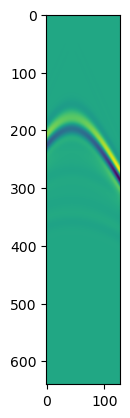

In [25]:
plt.imshow(y_data[10,:,:])

In [26]:
dt = 0.0030
dado = torch.from_numpy(y_data[100,:,:])

In [27]:
def plot_fft(dado):
    DATA = torch.sum(torch.abs(torch.fft.rfft(dado, 1024,dim=0)),dim=1)
    freq = torch.fft.rfftfreq(1024, dt)
    plt.plot(freq, DATA)
    plt.grid()
    plt.xlim(0,20)
    plt.xlabel('Freq (Hz)')
    plt.xticks(range(0, 20, 1))
    plt.title('Espectro de Amplitude ')
    plt.show()
    return

In [28]:
class BandpassFilter:
    def __init__(self, f1, f2,f3,f4, dt, N=500):

        self.f1 = f1
        self.f2 = f2
        self.f3 = f3
        self.f4 = f4
        self.dt = dt
        self.N = N

        A = (f1 + f2) * dt
        B = (f2 - f1) * dt
        C = (f3 + f4) * dt
        D = (f4 - f3) * dt

        n = torch.arange(-N, N + 1)

        self.kernel = (
            C * torch.sinc(C * n) * torch.sinc(D * n)
            - A * torch.sinc(A * n) * torch.sinc(B * n)
        )

    def __call__(self, data, axis=1):

        tam = data.shape[axis] + len(self.kernel) - 1

        data_fft = torch.fft.fft(data, n=tam, dim=axis)
        filt_fft = torch.fft.fft(self.kernel, n=tam)

        shape = [1] * data.ndim
        shape[axis] = tam

        filt_fft = filt_fft.reshape(shape)

        filtered = torch.fft.ifft(
            data_fft * filt_fft,
            n=tam,
            dim=axis
        ).real

        slc = [slice(None)] * filtered.ndim
        slc[axis] = slice(self.N, -self.N)

        return filtered[tuple(slc)]

In [29]:
bp = BandpassFilter(
    f1=4.5,
    f2=6.5,
    f3= 1/(2*dt),
    f4=1/(2*dt) ,
    dt=0.003,
    N=500
)

shot_filtered = bp(dado, axis=0)

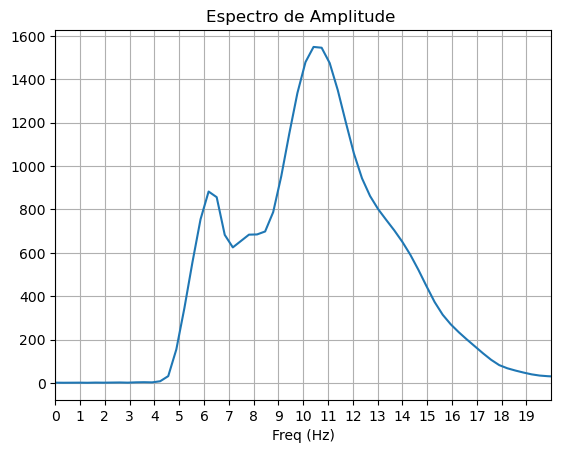

In [30]:
plot_fft(shot_filtered)

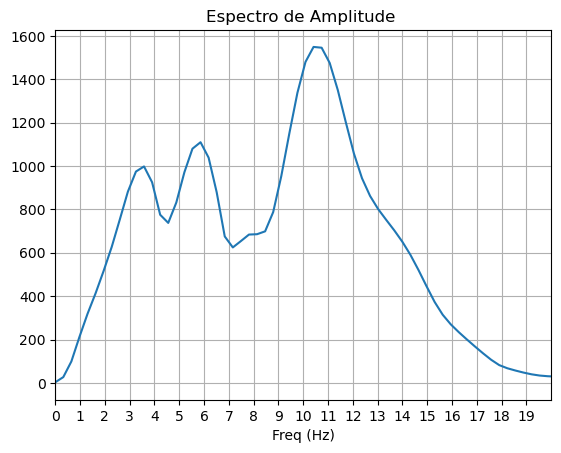

In [31]:
plot_fft(dado)

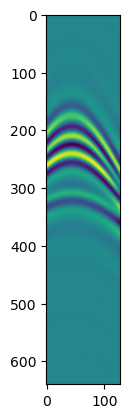

In [32]:
plt.imshow(shot_filtered)

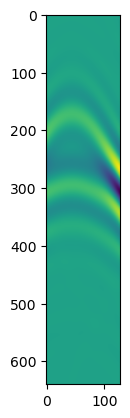

In [33]:
plt.imshow(dado-shot_filtered)

In [34]:
y_data.shape

(375, 640, 128)

In [35]:
y_data_filt=[]

for i in range(y_data.shape[0]):
    aux = bp(torch.from_numpy(y_data[i,:,:]), axis=0)
    y_data_filt.append(aux)
y_data_filt=np.array(y_data_filt)

In [36]:
np.save('input.npy',y_data_filt)
np.save('output.npy',y_data)